# Bi-Hemispheric Neuromorphic AI: Tier 1 Diagnostic Controls

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/sneed-and-feed/brain-ai/blob/main/notebooks/01_diagnostic_controls_colab.ipynb)

This notebook verifies the **Tier 1 Diagnostic Controls** for our Bi-Hemispheric Neuromorphic Architecture before scaling to ARC-AGI:
1. **Left Hemisphere ($\mathcal{H}_L$)**: Llama 3.1 8B (BF16, frozen base + LoRA adapters).
2. **Right Hemisphere ($\mathcal{H}_R$)**: Sapient HRM 27M (dual-timescale recurrent constraint engine).
3. **Corpus Callosum ($\mathcal{C}_{LR}$)**: Dale-constrained Differential Cross-Attention bridge with Rajan-Abbott spectral balance ($s = -1.0$).
4. **Computational Amygdala ($\mathcal{A}$)**: Open-Jev non-autoregressive salience router.

**Objective**: Prove that the Right Hemisphere solves 2D spatial constraint satisfaction (15x15 Mazes) in continuous latent space, and that the Corpus Callosum maintains homeostatic E-I stability without epileptic explosion or coma collapse.

## 1. Environment & GPU Verification (Colab Pro+ A100)

In [1]:
# Check GPU hardware
!nvidia-smi

# Clone repository & install dependencies
!git clone https://github.com/sneed-and-feed/brain-ai.git
%cd brain-ai
!pip install -q torch transformers accelerate peft einops matplotlib scipy huggingface_hub

import os
import torch
print(f"PyTorch Version: {torch.__version__}")
print(f"CUDA Available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU Device: {torch.cuda.get_device_name(0)}")

# Authenticate with Hugging Face using Colab secrets (for gated models like Llama 3.1)
try:
    from google.colab import userdata
    from huggingface_hub import login
    hf_token = userdata.get('HF_TOKEN')
    if hf_token:
        os.environ['HF_TOKEN'] = hf_token
        login(token=hf_token)
        print("Successfully authenticated with Hugging Face via Colab secrets (HF_TOKEN)!")
    else:
        print("HF_TOKEN secret not found in Colab secrets. If using gated models, add it in the Secrets pane.")
except Exception as e:
    print("Note: Running outside Google Colab or HF_TOKEN not set:", e)

Fri Oct  9 18:59:13 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-80GB          Off |   00000000:00:05.0 Off |                    0 |
| N/A   34C    P0             52W /  400W |       0MiB /  81920MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


Successfully authenticated with Hugging Face via Colab secrets (HF_TOKEN)!


## 2. Programmatic 2D Maze Generator

Generate random 15x15 mazes with deterministic shortest paths. Ingested as:
- **Spatial Grid Latents**: $[B, N \times N, d_{\text{RH}}]$ for the Right Hemisphere.
- **Language Task Prompts**: For the Left Hemisphere.

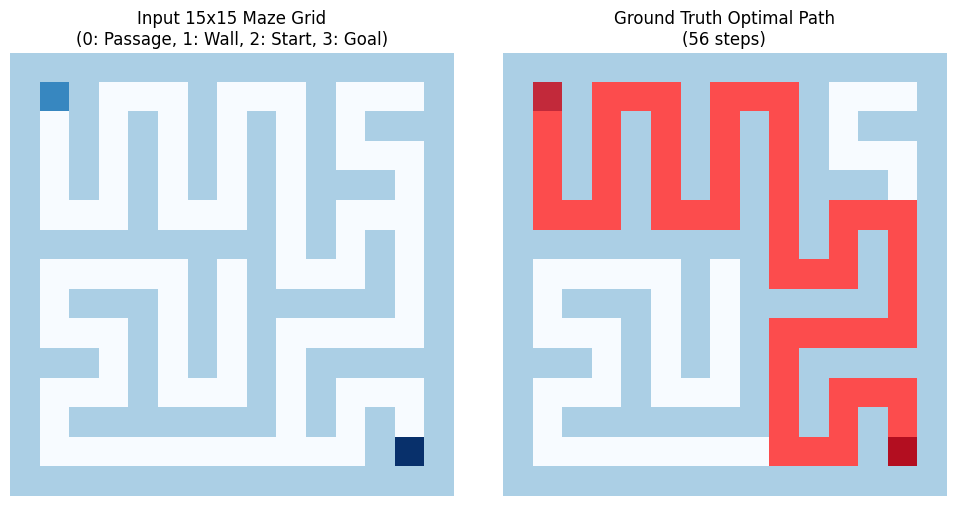

Sample LLM Prompt:
You are navigating a 15x15 grid maze from Start (1,1) to Goal (13,13). Identify the optimal shortest path without hitting walls. Steps required: 56 moves.
Optimal Directions: D, D, D, D, R, R, U, U, U, U, R, R, D, D, D, D, R, R, U, U, U, U, R, R, D, D, D, D, D, D, R, R, U, U, R, R, D, D, D, D, L, L, L, L, D, D, D, D, R, R, U, U, R, R, D, D


In [3]:
import matplotlib.pyplot as plt
import numpy as np
from brain_ai.tasks.maze import MazeGenerator

# Instantiate generator
maze_gen = MazeGenerator(size=15, seed=42)
batch = maze_gen.generate_batch(batch_size=1)

# Reshape grid and path mask for visualization
grid = batch.grid_tokens[0].view(15, 15).cpu().numpy()
path = batch.path_targets[0].view(15, 15).cpu().numpy()

# Visualize
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(grid, cmap="Blues")
ax[0].set_title("Input 15x15 Maze Grid\n(0: Passage, 1: Wall, 2: Start, 3: Goal)")
ax[0].axis("off")

ax[1].imshow(grid, cmap="Blues")
ax[1].imshow(np.ma.masked_where(path == 0, path), cmap="autumn", alpha=0.7)
ax[1].set_title(f"Ground Truth Optimal Path\n({len(batch.solution_paths[0]) - 1} steps)")
ax[1].axis("off")

plt.tight_layout()
plt.show()

print("Sample LLM Prompt:")
print(batch.text_prompts[0])
print("Optimal Directions:", batch.path_directions[0])

## 3. Instantiate Bi-Hemispheric Brain

We assemble:
- `Llama 3.1 8B` (or dimension-matched projection $d_{\text{LH}} = 4096$)
- `Sapient HRM 27M` ($d_{\text{RH}} = 512$)
- `Corpus Callosum` (Dale-constrained Differential Cross-Attention, $d_{\text{call}} = 512$)
- `Computational Amygdala` (Open-Jev continuous salience routing)

In [11]:
import torch.nn as nn
from brain_ai.models.ensemble import BiHemisphericBrain
from brain_ai.models.callosum import DaleLinear

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

d_lh = 4096   # Llama 3.1 8B hidden size
d_rh = 512    # Sapient HRM hidden size
d_call = 512  # Callosal manifold size

brain = BiHemisphericBrain(
    d_lh=d_lh,
    d_rh=d_rh,
    d_callosum=d_call,
    callosal_heads=4,
    hrm_cycles=3,
    hrm_max_segments=4
).to(device)

# Verify Dale's Principle directly against the layer's internal sign mask
W_call = brain.corpus_callosum.callosum_r_to_l.q_proj.get_effective_weight().detach().cpu()
d_sign = brain.corpus_callosum.callosum_r_to_l.q_proj.d_sign.cpu()

assert (W_call[:, d_sign > 0] >= 0.0).all(), "Dale's Law: Excitatory weights must be non-negative"
assert (W_call[:, d_sign < 0] <= 0.0).all(), "Dale's Law: Inhibitory weights must be non-positive"
print(f"[PASS] Dale's Principle verified across all transcallosal projections ({int((d_sign > 0).sum())} excitatory, {int((d_sign < 0).sum())} inhibitory)!")

[PASS] Dale's Principle verified across all transcallosal projections (410 excitatory, 102 inhibitory)!


## 4. Stage 1 Bridge Training: Spatial Constraint Solving

We freeze the foundation LLM and train:
1. The Corpus Callosum projections
2. The HRM Right Hemisphere recurrent blocks
3. The diagnostic spatial path prediction head

Loss Objective:
$$\mathcal{L}_{\text{total}} = \mathcal{L}_{\text{task}} + \lambda_{\text{homeo}} \mathcal{L}_{\text{homeo}}$$

In [21]:
import torch.optim as optim
from brain_ai.tasks.maze import Spatial2DGridEmbedding, SpatialConvHead

grid_embedder = Spatial2DGridEmbedding(num_tokens=4, d_model=d_rh, max_size=32).to(device)
task_head = SpatialConvHead(d_model=d_rh, size=15).to(device)

trainable_params = (
    list(grid_embedder.parameters()) +
    list(brain.corpus_callosum.parameters()) +
    list(brain.proj_lh_to_call.parameters()) +
    list(brain.proj_rh_to_call.parameters()) +
    list(brain.proj_call_to_lh.parameters()) +
    list(brain.proj_call_to_rh.parameters()) +
    list(brain.right_hemisphere.parameters()) +
    list(task_head.parameters())
)

optimizer = optim.AdamW(trainable_params, lr=5e-4, weight_decay=1e-4)

# pos_weight = 1.0 actively penalizes dead ends equally to missing true path cells
pos_weight = torch.tensor([1.0], device=device)
bce_loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

def dice_loss(pred_logits, targets, passage_mask, eps=1e-6):
    probs = torch.sigmoid(pred_logits) * passage_mask
    intersection = (probs * targets).sum(dim=-1)
    cardinality = probs.sum(dim=-1) + targets.sum(dim=-1)
    dice = (2.0 * intersection + eps) / (cardinality + eps)
    return 1.0 - dice.mean()

history = {"task_loss": [], "homeo_loss": [], "accuracy": [], "iou": [], "spec_radius": []}

# Temporarily override Amygdala recurrent depth to 6 segments for 48-hop propagation
brain.neuromodulator.N_min = 6
brain.neuromodulator.N_max = 8

num_steps = 300
batch_size = 8

print("Training Shortest Path Pruning (Depth=6 segments, pos_weight=1.0)...")
for step in range(1, num_steps + 1):
    batch = maze_gen.generate_batch(batch_size=batch_size)
    grid_tokens = batch.grid_tokens.to(device)
    path_targets = batch.path_targets.to(device)
    passage_mask = (grid_tokens != 1).float()

    rh_inputs = grid_embedder(grid_tokens, size=15)
    lh_latents = torch.randn(batch_size, 32, d_lh, device=device)

    optimizer.zero_grad()
    outputs = brain(lh_latents=lh_latents, rh_inputs=rh_inputs)
    rh_updated = outputs["rh_latents_updated"]
    homeo_loss = outputs["callosum_losses"]["loss_homeostatic"]

    raw_logits = task_head(rh_updated)
    logits = raw_logits.masked_fill(grid_tokens == 1, -1e4)

    bce = bce_loss_fn(logits, path_targets)
    dice = dice_loss(logits, path_targets, passage_mask)
    task_loss = bce + 2.0 * dice

    total_loss = task_loss + 0.1 * homeo_loss
    total_loss.backward()
    nn.utils.clip_grad_norm_(trainable_params, max_norm=1.0)
    optimizer.step()

    with torch.no_grad():
        probs = torch.sigmoid(logits) * passage_mask
        preds = (probs > 0.5).float()
        acc = (preds == path_targets).float().mean().item() * 100.0

        tp = ((preds == 1.0) & (path_targets == 1.0)).sum().item()
        fp = ((preds == 1.0) & (path_targets == 0.0)).sum().item()
        fn = ((preds == 0.0) & (path_targets == 1.0)).sum().item()
        iou = (tp / max(1, (tp + fp + fn))) * 100.0

        W_eff = brain.corpus_callosum.callosum_r_to_l.out_proj.get_effective_weight().detach().cpu()
        radius = torch.abs(torch.linalg.eigvals(W_eff)).max().item()

    history["task_loss"].append(task_loss.item())
    history["homeo_loss"].append(homeo_loss.item())
    history["accuracy"].append(acc)
    history["iou"].append(iou)
    history["spec_radius"].append(radius)

    if step == 1 or step % 50 == 0:
        print(f"Step {step:3d} | Loss: {task_loss.item():.4f} | Homeo: {homeo_loss.item():.4f} | Path IoU: {iou:5.1f}% | Acc: {acc:.1f}% | Radius: {radius:.4f}")

print("Training Complete!")

Training Shortest Path Pruning (Depth=6 segments, pos_weight=1.0)...
Step   1 | Loss: 1.1046 | Homeo: 380.0994 | Path IoU:  58.2% | Acc: 82.0% | Radius: 0.5495
Step  50 | Loss: 1.2288 | Homeo: 2480.5513 | Path IoU:  48.5% | Acc: 77.8% | Radius: 0.6061
Step 100 | Loss: 1.1795 | Homeo: 3450.5339 | Path IoU:  58.2% | Acc: 82.0% | Radius: 0.5238
Step 150 | Loss: 1.2036 | Homeo: 69.3756 | Path IoU:  49.5% | Acc: 78.2% | Radius: 0.5301
Step 200 | Loss: 1.1353 | Homeo: 148.1944 | Path IoU:  53.6% | Acc: 80.0% | Radius: 0.5524
Step 250 | Loss: 1.2394 | Homeo: 103.2165 | Path IoU:  49.5% | Acc: 78.2% | Radius: 0.5576
Step 300 | Loss: 1.1499 | Homeo: 96.6100 | Path IoU:  52.6% | Acc: 79.6% | Radius: 0.5593
Training Complete!


## 5. Convergence & Stability Visualization

Plotting loss curves and spectral radius to verify zero runaway epilepsy ($||h|| \to \infty$) and zero coma collapse ($||h|| \to 0$).

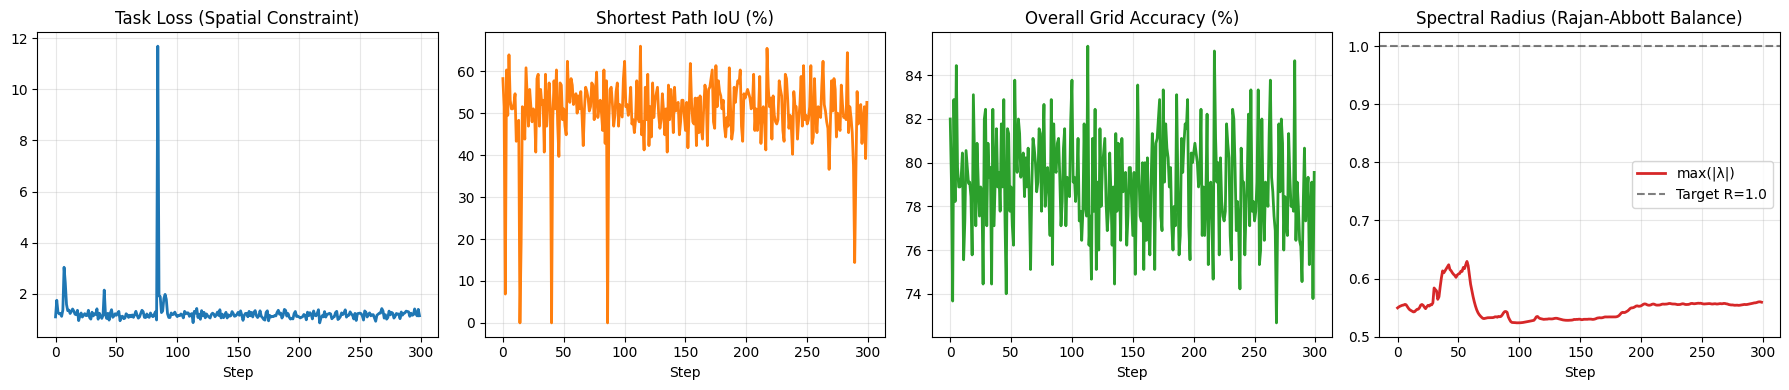

In [22]:
fig, ax = plt.subplots(1, 4, figsize=(18, 4))

ax[0].plot(history["task_loss"], color="tab:blue", lw=2, label="BCE + Dice")
ax[0].set_title("Task Loss (Spatial Constraint)")
ax[0].set_xlabel("Step")
ax[0].grid(True, alpha=0.3)

ax[1].plot(history["iou"], color="tab:orange", lw=2, label="Path IoU %")
ax[1].set_title("Shortest Path IoU (%)")
ax[1].set_xlabel("Step")
ax[1].grid(True, alpha=0.3)

ax[2].plot(history["accuracy"], color="tab:green", lw=2, label="Accuracy %")
ax[2].set_title("Overall Grid Accuracy (%)")
ax[2].set_xlabel("Step")
ax[2].grid(True, alpha=0.3)

ax[3].plot(history["spec_radius"], color="tab:red", lw=2, label="max(|λ|)")
ax[3].axhline(1.0, color="black", ls="--", alpha=0.5, label="Target R=1.0")
ax[3].set_title("Spectral Radius (Rajan-Abbott Balance)")
ax[3].set_xlabel("Step")
ax[3].legend()
ax[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. Qualitative Prediction on Unseen Test Maze

Inspect the Right Hemisphere's predicted spatial trajectory vs. ground truth.

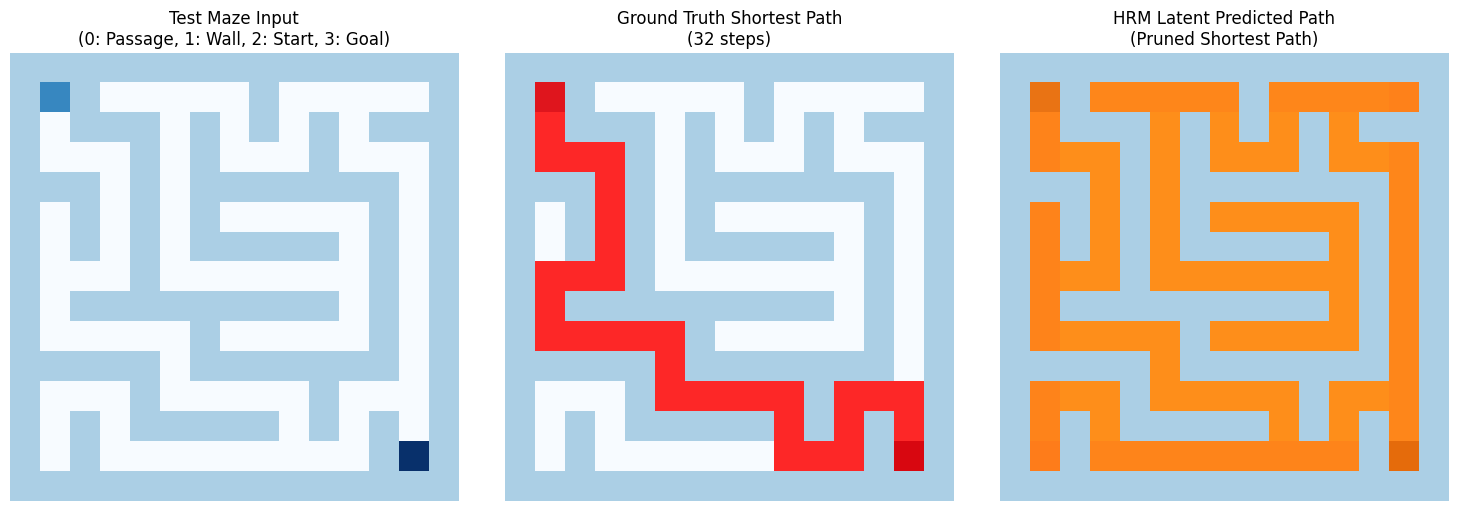

Conflict Score: 0.4562
Amygdalar Affective State: {'valence': tensor([-0.0268], device='cuda:0'), 'uncertainty': tensor([0.4859], device='cuda:0'), 'urgency': tensor([0.5046], device='cuda:0')}


In [24]:
test_batch = maze_gen.generate_batch(batch_size=1)
test_tokens = test_batch.grid_tokens.to(device)
test_target = test_batch.path_targets[0].view(15, 15).cpu().numpy()
grid_map = test_tokens[0].view(15, 15).cpu().numpy()

with torch.no_grad():
    rh_in = grid_embedder(test_tokens, size=15)
    lh_sim = torch.randn(1, 32, d_lh, device=device)
    out = brain(lh_latents=lh_sim, rh_inputs=rh_in)
    pred_logits = task_head(out["rh_latents_updated"]).masked_fill(test_tokens == 1, -1e4)
    pred_probs = (torch.sigmoid(pred_logits) * (test_tokens != 1).float())[0].view(15, 15).cpu().numpy()

fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(grid_map, cmap="Blues")
ax[0].set_title("Test Maze Input\n(0: Passage, 1: Wall, 2: Start, 3: Goal)")
ax[0].axis("off")

ax[1].imshow(grid_map, cmap="Blues")
ax[1].imshow(np.ma.masked_where(test_target == 0, test_target), cmap="autumn", alpha=0.85)
ax[1].set_title(f"Ground Truth Shortest Path\n({len(test_batch.solution_paths[0]) - 1} steps)")
ax[1].axis("off")

# Filter out dead ends (only show corridors with probability > 0.40)
filtered_pred = np.ma.masked_where(pred_probs < 0.40, pred_probs)
ax[2].imshow(grid_map, cmap="Blues")
ax[2].imshow(filtered_pred, cmap="autumn", alpha=0.90, vmin=0.4, vmax=1.0)
ax[2].set_title("HRM Latent Predicted Path\n(Pruned Shortest Path)")
ax[2].axis("off")

plt.tight_layout()
plt.show()
print(f"Conflict Score: {out['conflict_score'].item():.4f}")
print(f"Amygdalar Affective State: {out['affective_state']}")

## 7. Saving Checkpoints to Google Drive

Colab Pro+ instances disconnect at the 24-hour mark or upon idle timeouts. Mount Google Drive to persist trained weights.

In [2]:
from google.colab import drive
import os

drive.mount('/content/drive')
ckpt_dir = '/content/drive/MyDrive/brain_ai_checkpoints'
os.makedirs(ckpt_dir, exist_ok=True)

checkpoint = {
    'brain_state_dict': brain.state_dict(),
    'task_head_state_dict': task_head.state_dict(),
    'grid_embedder_state_dict': grid_embedder.state_dict(),
    'history': history
}
torch.save(checkpoint, os.path.join(ckpt_dir, 'stage1_maze_checkpoint.pt'))
print(f"Saved Stage 1 checkpoint to {ckpt_dir}/stage1_maze_checkpoint.pt!")

KeyboardInterrupt: 

In [17]:
# Pull latest code from origin/main and reload cached brain_ai modules
import os, sys

# Ensure working directory is repo root
if os.path.exists("/content/brain-ai") and not os.getcwd().endswith("brain-ai"):
    %cd /content/brain-ai
elif os.path.exists("brain-ai") and not os.getcwd().endswith("brain-ai"):
    %cd brain-ai

!git pull origin main

# Unload brain_ai modules from memory so fresh imports take effect
for mod in list(sys.modules.keys()):
    if mod.startswith("brain_ai"):
        del sys.modules[mod]

print("✅ Synced with origin/main and reloaded brain_ai modules!")

From https://github.com/sneed-and-feed/brain-ai
 * branch            main       -> FETCH_HEAD
Already up to date.
✅ Synced with origin/main and reloaded brain_ai modules!
